# Just for 501 plotting - random :D

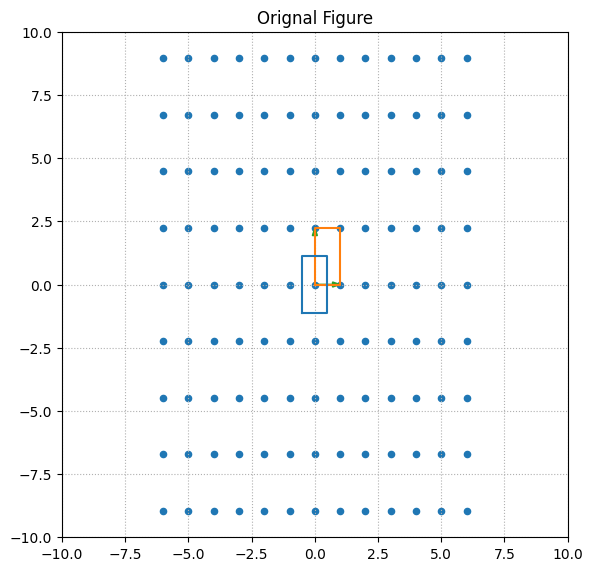

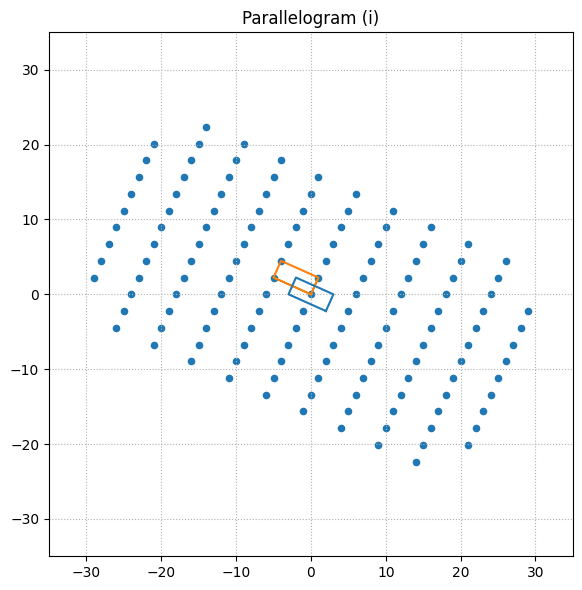

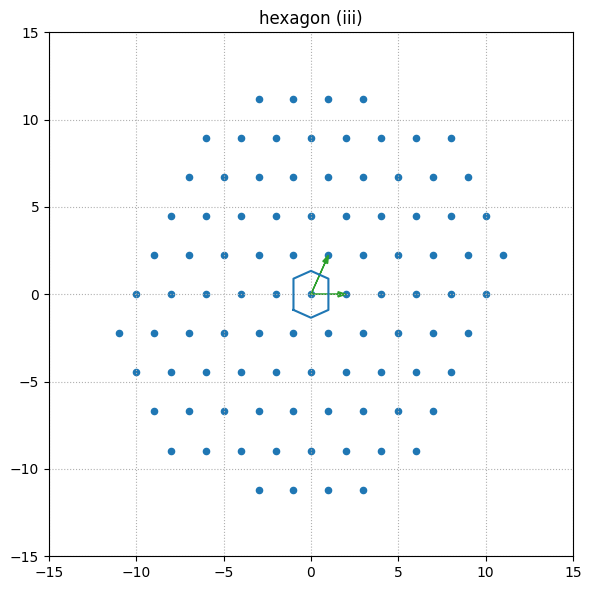

In [10]:
import numpy as np
import math
import matplotlib.pyplot as plt

sqrt5 = math.sqrt(5)

# Helper function: complex multiplication by (1+i√5)
def T_1_i_sqrt5(xy):
    z = xy[0] + 1j*xy[1]
    w = (1 + 1j*sqrt5) * z
    return np.array([w.real, w.imag])

def apply_linear_to_polygon(poly, f):
    return np.array([f(p) for p in poly])

# Helper: generate lattice points with limited "radial" cutoff (avoid clutter)
def lattice_points(v1, v2, nrange=4, rmax=12):
    pts = []
    for a in range(-nrange, nrange+1):
        for b in range(-nrange, nrange+1):
            p = a*v1 + b*v2
            if np.linalg.norm(p) <= rmax:
                pts.append(p)
    return np.array(pts)

# A) L = {a + b i√5}
v1_L = np.array([1.0,0.0])
v2_L = np.array([0.0,sqrt5])
L_pts = lattice_points(v1_L, v2_L, nrange=6, rmax=12)

# fundamental cell + Voronoi cell for L
F_rect = np.array([[0,0], v1_L, v1_L+v2_L, v2_L])
V_rect = np.array([[-0.5, -sqrt5/2],
                   [ 0.5, -sqrt5/2],
                   [ 0.5,  sqrt5/2],
                   [-0.5,  sqrt5/2]])

figA, axA = plt.subplots(figsize=(6,6))
axA.scatter(L_pts[:,0], L_pts[:,1], s=20)
axA.plot(np.r_[F_rect[:,0], F_rect[0,0]], np.r_[F_rect[:,1], F_rect[0,1]], color='C1')
axA.plot(np.r_[V_rect[:,0], V_rect[0,0]], np.r_[V_rect[:,1], V_rect[0,1]], color='C0')
axA.arrow(0,0,v1_L[0],v1_L[1], head_width=0.2, length_includes_head=True, color='C2')
axA.arrow(0,0,v2_L[0],v2_L[1], head_width=0.2, length_includes_head=True, color='C2')
axA.set_aspect('equal','box')
axA.set_xlim(-10,10); axA.set_ylim(-10,10)
axA.set_title("Orignal Figure")
axA.grid(True, linestyle=':')
figA.tight_layout()

# B) (1+i√5)L
L2_pts = np.array([T_1_i_sqrt5(p) for p in L_pts])
F_rect2 = apply_linear_to_polygon(F_rect, T_1_i_sqrt5)
V_rect2 = apply_linear_to_polygon(V_rect, T_1_i_sqrt5)

figB, axB = plt.subplots(figsize=(6,6))
axB.scatter(L2_pts[:,0], L2_pts[:,1], s=20)
axB.plot(np.r_[F_rect2[:,0], F_rect2[0,0]], np.r_[F_rect2[:,1], F_rect2[0,1]], color='C1')
axB.plot(np.r_[V_rect2[:,0], V_rect2[0,0]], np.r_[V_rect2[:,1], V_rect2[0,1]], color='C0')
Te1 = T_1_i_sqrt5(v1_L); Te2 = T_1_i_sqrt5(v2_L)
axB.arrow(0,0,Te1[0],Te1[1], head_width=0.3, length_includes_head=True, color='C2')
axB.arrow(0,0,Te2[0],Te2[1], head_width=0.3, length_includes_head=True, color='C2')
axB.set_aspect('equal','box')
axB.set_xlim(-35,35); axB.set_ylim(-35,35)
axB.set_title("Parallelogram (i)")
axB.grid(True, linestyle=':')
figB.tight_layout()

# C) L' = {2a+(1+i√5)b}
v1_p = np.array([2.0,0.0])
v2_p = np.array([1.0,sqrt5])
w = v2_p - v1_p
Lp_pts = lattice_points(v1_p, v2_p, nrange=5, rmax=12)

# Compute Voronoi hexagon as before
def constraints_from_vectors(vecs):
    cons = []
    for v in vecs:
        b = 0.5*np.dot(v,v)
        cons.append((v,b))
        cons.append((-v,b))
    return cons

def intersect_lines(v1,b1,v2,b2):
    A = np.stack([v1,v2],axis=0)
    det = np.linalg.det(A)
    if abs(det)<1e-9: return None
    return np.linalg.solve(A,np.array([b1,b2]))

cons = constraints_from_vectors([v1_p,v2_p,w])
candidates = []
for i in range(len(cons)):
    for j in range(i+1,len(cons)):
        p = intersect_lines(cons[i][0],cons[i][1],cons[j][0],cons[j][1])
        if p is None: continue
        ok=True
        for (v,b) in cons:
            if np.dot(v,p)-b>1e-8:
                ok=False; break
        if ok: candidates.append(p)
def unique_points(pts,tol=1e-6):
    out=[]
    for p in pts:
        if not any(np.linalg.norm(p-q)<tol for q in out): out.append(p)
    return out
verts = unique_points(candidates)
center = np.mean(verts,axis=0)
angles = np.arctan2([p[1]-center[1] for p in verts],[p[0]-center[0] for p in verts])
order = np.argsort(angles)
Vpoly = np.array([verts[k] for k in order])

figC, axC = plt.subplots(figsize=(6,6))
axC.scatter(Lp_pts[:,0], Lp_pts[:,1], s=20)
axC.plot(np.r_[Vpoly[:,0],Vpoly[0,0]], np.r_[Vpoly[:,1],Vpoly[0,1]], color='C0')
axC.arrow(0,0,v1_p[0],v1_p[1], head_width=0.3, length_includes_head=True, color='C2')
axC.arrow(0,0,v2_p[0],v2_p[1], head_width=0.3, length_includes_head=True, color='C2')
axC.set_aspect('equal','box')
axC.set_xlim(-15,15); axC.set_ylim(-15,15)
axC.set_title("hexagon (iii)")
axC.grid(True, linestyle=':')
figC.tight_layout()
